# Results Analysis (from raw CSV files)

This notebook reads directly from the raw result CSV files in `PathBoost_results/`, `GNN_results/`, and `Kernel_results/` directories, so it always reflects the latest runs. No manual merging step required.

**Metrics reported:** accuracy, balanced_accuracy, f1, f1_macro, recall, roc_auc (+ training time)  
**Algorithms:** PathBoost, GNN (GIN/GINE), Graph Kernels (7 variants)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from itables import init_notebook_mode, show

init_notebook_mode(all_interactive=True)

# Colors
COLOR_PB = '#2ecc71'
COLOR_GNN = '#3498db'
COLOR_KERNEL = '#9b59b6'

BASE_DIR = os.path.join(os.path.dirname(os.getcwd())) if os.path.basename(os.getcwd()) == 'results_csv_files' else os.getcwd()


def load_all_results(directory_pattern):
    """Load all CSV files from a directory, keep latest result per (Dataset, Metric)."""
    files = sorted(glob.glob(directory_pattern))
    if not files:
        print(f"  No files found for pattern: {directory_pattern}")
        return pd.DataFrame()

    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f)
            df['_source_file'] = os.path.basename(f)
            dfs.append(df)
        except Exception as e:
            print(f"  Skipping {f}: {e}")

    if not dfs:
        return pd.DataFrame()

    combined = pd.concat(dfs, ignore_index=True)

    # Drop FAILED / TIMEOUT rows
    for col in ['Mean', 'Std_Top10', 'Std_All100', 'Training_Time_Mean', 'Training_Time_Std']:
        if col in combined.columns:
            combined = combined[~combined[col].astype(str).isin(['FAILED', 'TIMEOUT'])]

    # Convert numeric columns
    for col in ['Mean', 'Std_Top10', 'Std_All100', 'Training_Time_Mean', 'Training_Time_Std']:
        if col in combined.columns:
            combined[col] = pd.to_numeric(combined[col], errors='coerce')

    # Drop NaN means
    combined = combined.dropna(subset=['Mean'])

    # Keep latest per (Dataset, Metric) — filenames contain timestamps so sorting works
    combined = combined.sort_values('_source_file')
    combined = combined.drop_duplicates(subset=['Dataset', 'Metric'], keep='last')
    combined = combined.drop(columns=['_source_file'])

    return combined.reset_index(drop=True)


# Load data
print("Loading PathBoost results...")
df_pb = load_all_results(os.path.join(BASE_DIR, 'PathBoost_results', '*.csv'))
print(f"  {len(df_pb)} rows, {df_pb['Dataset'].nunique()} datasets")

print("Loading GNN results...")
df_gnn = load_all_results(os.path.join(BASE_DIR, 'GNN_results', '*.csv'))
print(f"  {len(df_gnn)} rows, {df_gnn['Dataset'].nunique()} datasets")

print("Loading Kernel results...")
df_kernel = load_all_results(os.path.join(BASE_DIR, 'Kernel_results', '*.csv'))
print(f"  {len(df_kernel)} rows, {df_kernel['Dataset'].nunique()} datasets")

Loading PathBoost results...
  189 rows, 36 datasets
Loading GNN results...
  238 rows, 43 datasets
Loading Kernel results...
  14 rows, 2 datasets


## Accuracy Comparison

In [2]:
# PathBoost accuracy
pb_acc = df_pb[df_pb['Metric'] == 'accuracy'][['Dataset', 'Mean', 'Std_Top10']].copy()
pb_acc = pb_acc.rename(columns={'Mean': 'PB_Accuracy', 'Std_Top10': 'PB_Std'})

# GNN accuracy
gnn_acc = df_gnn[df_gnn['Metric'] == 'accuracy'][['Dataset', 'Mean', 'Std_Top10']].copy()
gnn_acc = gnn_acc.rename(columns={'Mean': 'GNN_Accuracy', 'Std_Top10': 'GNN_Std'})

# Kernel: best accuracy across all kernel variants per dataset
kernel_acc_metrics = [m for m in df_kernel['Metric'].unique() if m.startswith('accuracy')]
if len(df_kernel) > 0 and len(kernel_acc_metrics) > 0:
    k_acc = df_kernel[df_kernel['Metric'].isin(kernel_acc_metrics)].copy()
    # Best kernel per dataset (highest mean)
    k_best = k_acc.loc[k_acc.groupby('Dataset')['Mean'].idxmax()]
    k_best = k_best[['Dataset', 'Mean', 'Std_Top10', 'Metric']].copy()
    k_best = k_best.rename(columns={'Mean': 'Kernel_Accuracy', 'Std_Top10': 'Kernel_Std', 'Metric': 'Kernel_Type'})
else:
    k_best = pd.DataFrame(columns=['Dataset', 'Kernel_Accuracy', 'Kernel_Std', 'Kernel_Type'])

# Merge
acc_df = pb_acc.merge(gnn_acc, on='Dataset', how='outer')
acc_df = acc_df.merge(k_best, on='Dataset', how='outer')
acc_df = acc_df.sort_values('Dataset').reset_index(drop=True)

# Multiply by 100 for percentage display
for col in ['PB_Accuracy', 'PB_Std', 'GNN_Accuracy', 'GNN_Std', 'Kernel_Accuracy', 'Kernel_Std']:
    if col in acc_df.columns:
        acc_df[col] = (acc_df[col] * 100).round(2)

# PB - GNN difference
acc_df['PB−GNN'] = (acc_df['PB_Accuracy'] - acc_df['GNN_Accuracy']).round(2)

print(f"Accuracy comparison: {len(acc_df)} datasets")
show(acc_df, scrollY='400px', scrollCollapse=True, paging=False)

Accuracy comparison: 43 datasets


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


## All Metrics Comparison

In [3]:
METRICS = ['accuracy', 'balanced_accuracy', 'f1', 'f1_macro', 'recall', 'roc_auc']


def format_mean_std(row, mean_col, std_col):
    """Format as 'mean ± std' percentage string."""
    m = row.get(mean_col)
    s = row.get(std_col)
    if pd.isna(m):
        return 'N/A'
    m_pct = m * 100
    if pd.isna(s):
        return f"{m_pct:.2f}"
    s_pct = s * 100
    return f"{m_pct:.2f} \u00b1 {s_pct:.2f}"


def build_wide_table(df, prefix):
    """Build wide columns for one algorithm."""
    rows = []
    for dataset in df['Dataset'].unique():
        d = df[df['Dataset'] == dataset]
        entry = {'Dataset': dataset}
        for metric in METRICS:
            mrow = d[d['Metric'] == metric]
            if len(mrow) > 0:
                r = mrow.iloc[0]
                entry[f"{prefix}_{metric}"] = format_mean_std(
                    {'m': r['Mean'], 's': r['Std_Top10']}, 'm', 's'
                )
            else:
                entry[f"{prefix}_{metric}"] = 'N/A'
        rows.append(entry)
    return pd.DataFrame(rows)


wide_pb = build_wide_table(df_pb, 'PB')
wide_gnn = build_wide_table(df_gnn, 'GNN')

# Kernel: only accuracy variants
if len(df_kernel) > 0 and len(kernel_acc_metrics) > 0:
    k_rows = []
    for dataset in df_kernel['Dataset'].unique():
        d = df_kernel[(df_kernel['Dataset'] == dataset) & (df_kernel['Metric'].isin(kernel_acc_metrics))]
        if len(d) > 0:
            best = d.loc[d['Mean'].idxmax()]
            k_rows.append({
                'Dataset': dataset,
                'Kernel_accuracy': f"{best['Mean']*100:.2f} \u00b1 {best['Std_Top10']*100:.2f}",
            })
    wide_kernel = pd.DataFrame(k_rows) if k_rows else pd.DataFrame(columns=['Dataset', 'Kernel_accuracy'])
else:
    wide_kernel = pd.DataFrame(columns=['Dataset', 'Kernel_accuracy'])

# Merge all
wide = wide_pb.merge(wide_gnn, on='Dataset', how='outer')
wide = wide.merge(wide_kernel, on='Dataset', how='outer')
wide = wide.sort_values('Dataset').reset_index(drop=True)
wide = wide.fillna('N/A')

print(f"Full metrics table: {len(wide)} datasets")
show(wide, scrollY='500px', scrollCollapse=True, paging=False)

Full metrics table: 45 datasets


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


## Per-Metric Bar Charts

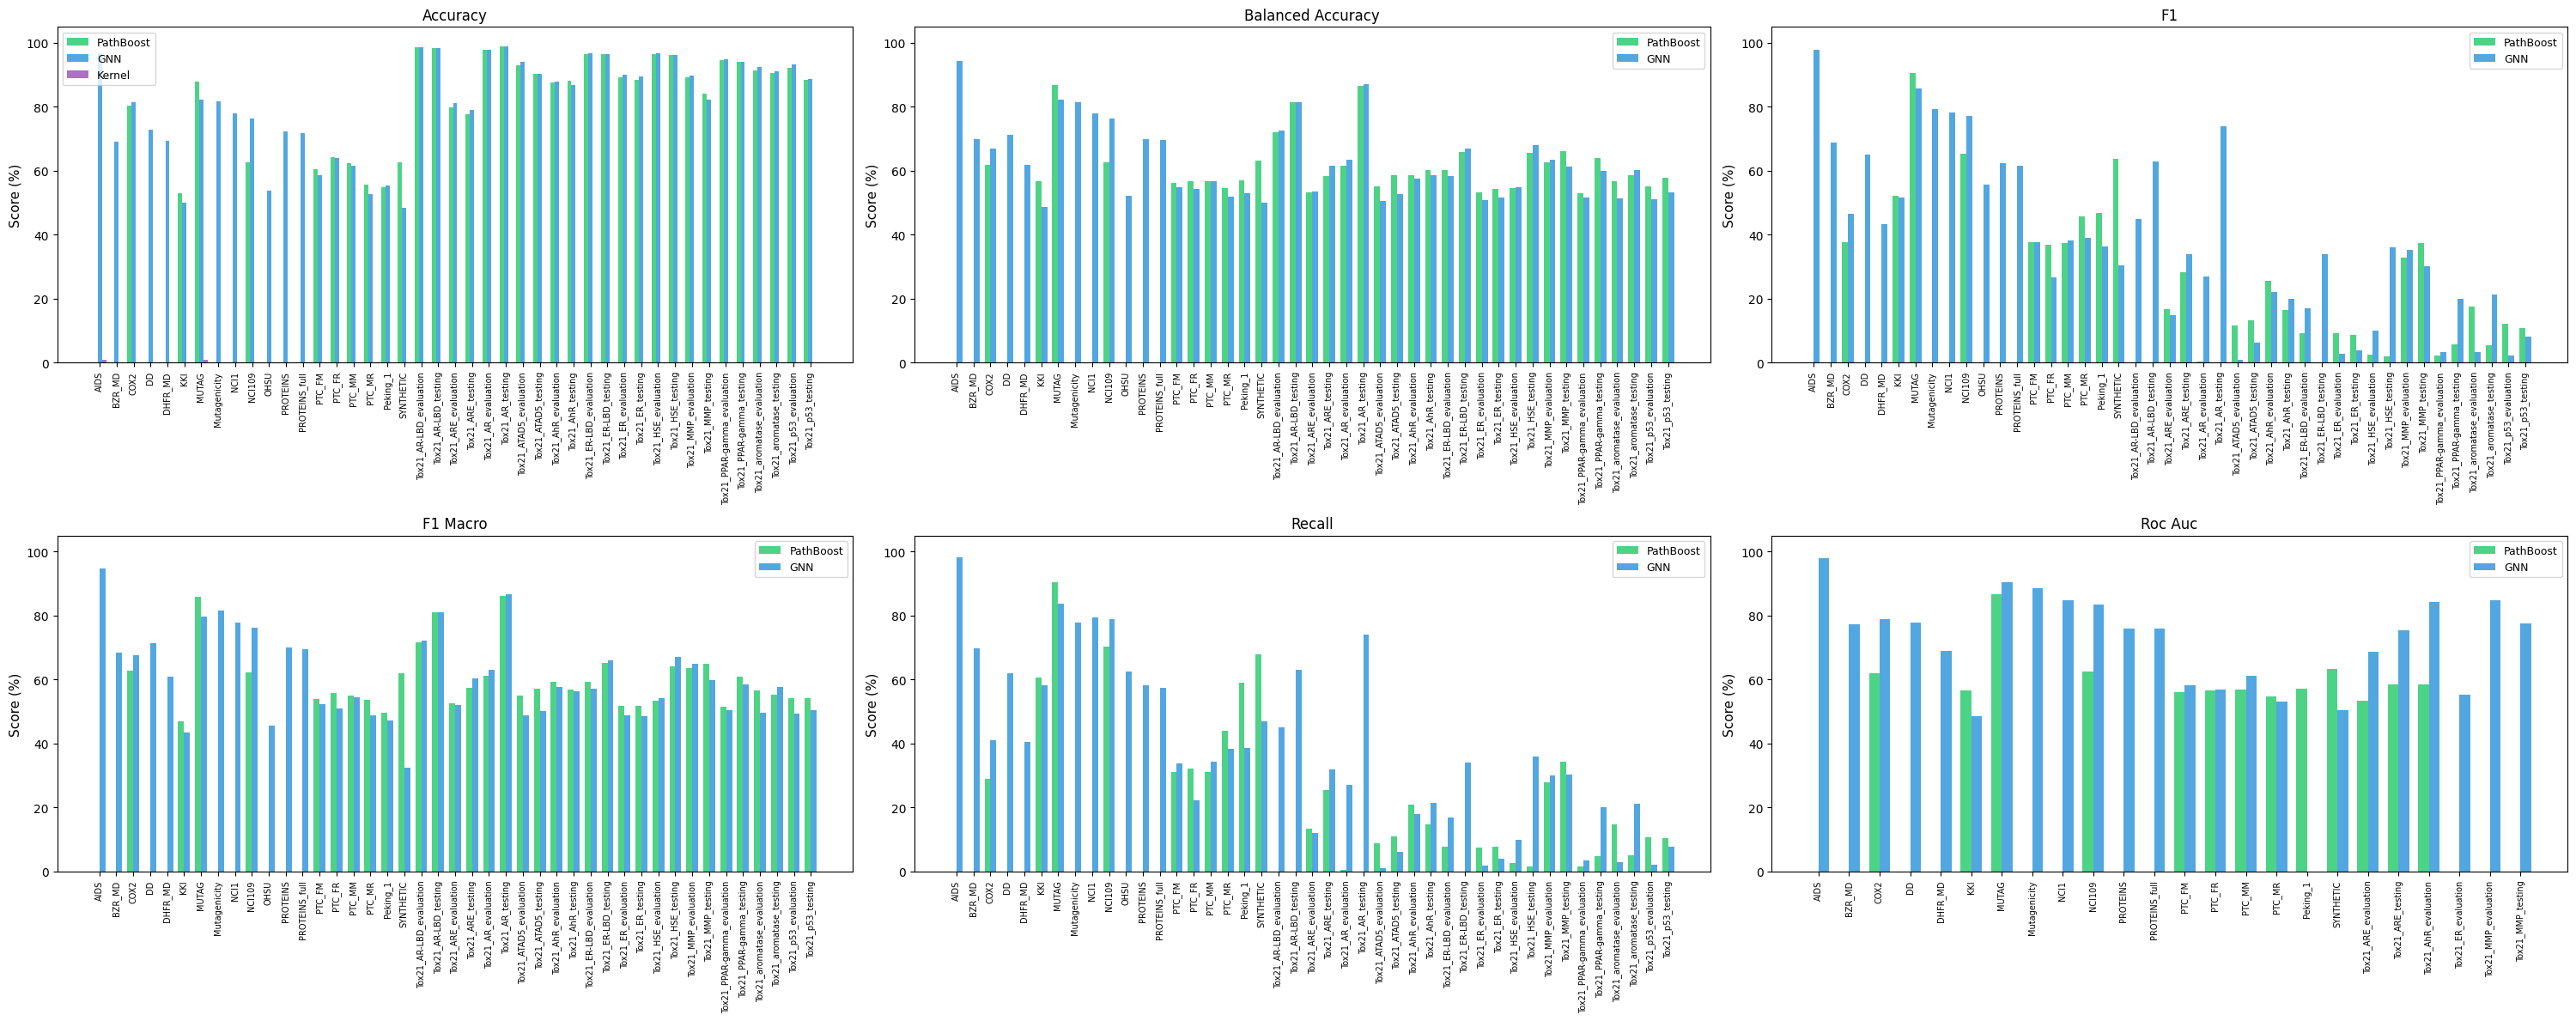

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(max(18, len(acc_df) * 0.7), 12))
axes = axes.flatten()

for idx, metric in enumerate(METRICS):
    ax = axes[idx]

    # Get PB data for this metric
    pb_m = df_pb[df_pb['Metric'] == metric][['Dataset', 'Mean']].copy()
    pb_m = pb_m.rename(columns={'Mean': 'PB'})

    # Get GNN data for this metric
    gnn_m = df_gnn[df_gnn['Metric'] == metric][['Dataset', 'Mean']].copy()
    gnn_m = gnn_m.rename(columns={'Mean': 'GNN'})

    # Merge
    chart_df = pb_m.merge(gnn_m, on='Dataset', how='outer')

    # For accuracy, add kernel
    if metric == 'accuracy' and len(k_best) > 0:
        k_chart = k_best[['Dataset', 'Kernel_Accuracy']].copy()
        k_chart['Kernel_Accuracy'] = k_chart['Kernel_Accuracy'] / 100  # undo earlier *100
        chart_df = chart_df.merge(k_chart, on='Dataset', how='outer')

    chart_df = chart_df.sort_values('Dataset').reset_index(drop=True)

    x = np.arange(len(chart_df))
    width = 0.35 if metric != 'accuracy' else 0.25

    if metric == 'accuracy' and 'Kernel_Accuracy' in chart_df.columns:
        ax.bar(x - width, chart_df['PB'].fillna(0) * 100, width, label='PathBoost', color=COLOR_PB, alpha=0.85)
        ax.bar(x, chart_df['GNN'].fillna(0) * 100, width, label='GNN', color=COLOR_GNN, alpha=0.85)
        ax.bar(x + width, chart_df['Kernel_Accuracy'].fillna(0), width, label='Kernel', color=COLOR_KERNEL, alpha=0.85)
    else:
        ax.bar(x - width / 2, chart_df['PB'].fillna(0) * 100, width, label='PathBoost', color=COLOR_PB, alpha=0.85)
        ax.bar(x + width / 2, chart_df['GNN'].fillna(0) * 100, width, label='GNN', color=COLOR_GNN, alpha=0.85)

    ax.set_title(metric.replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(chart_df['Dataset'], rotation=90, fontsize=7)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

## Win/Loss Summary

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


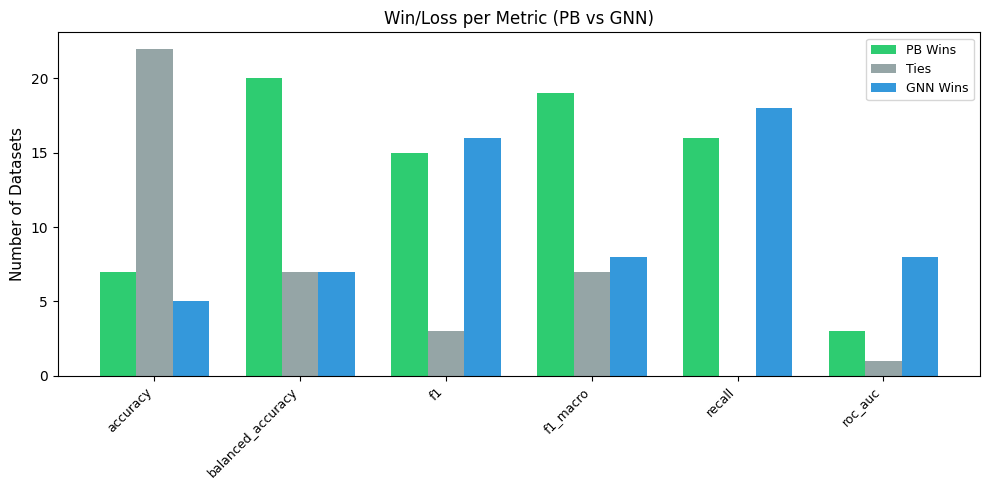

In [5]:
TIE_MARGIN = 0.01  # ±1% margin for ties

win_loss_rows = []
for metric in METRICS:
    pb_m = df_pb[df_pb['Metric'] == metric][['Dataset', 'Mean']].rename(columns={'Mean': 'PB'})
    gnn_m = df_gnn[df_gnn['Metric'] == metric][['Dataset', 'Mean']].rename(columns={'Mean': 'GNN'})
    merged = pb_m.merge(gnn_m, on='Dataset', how='inner')

    diff = merged['PB'] - merged['GNN']
    pb_wins = (diff > TIE_MARGIN).sum()
    gnn_wins = (diff < -TIE_MARGIN).sum()
    ties = (diff.abs() <= TIE_MARGIN).sum()

    win_loss_rows.append({
        'Metric': metric,
        'PB Wins': int(pb_wins),
        'GNN Wins': int(gnn_wins),
        'Ties (±1%)': int(ties),
        'Total': int(len(merged)),
    })

wl_df = pd.DataFrame(win_loss_rows)
show(wl_df, paging=False)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(wl_df))
width = 0.25

ax.bar(x - width, wl_df['PB Wins'], width, label='PB Wins', color=COLOR_PB)
ax.bar(x, wl_df['Ties (±1%)'], width, label='Ties', color='#95a5a6')
ax.bar(x + width, wl_df['GNN Wins'], width, label='GNN Wins', color=COLOR_GNN)

ax.set_xticks(x)
ax.set_xticklabels(wl_df['Metric'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of Datasets', fontsize=11)
ax.set_title('Win/Loss per Metric (PB vs GNN)', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Training Time

Training times: 43 datasets


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


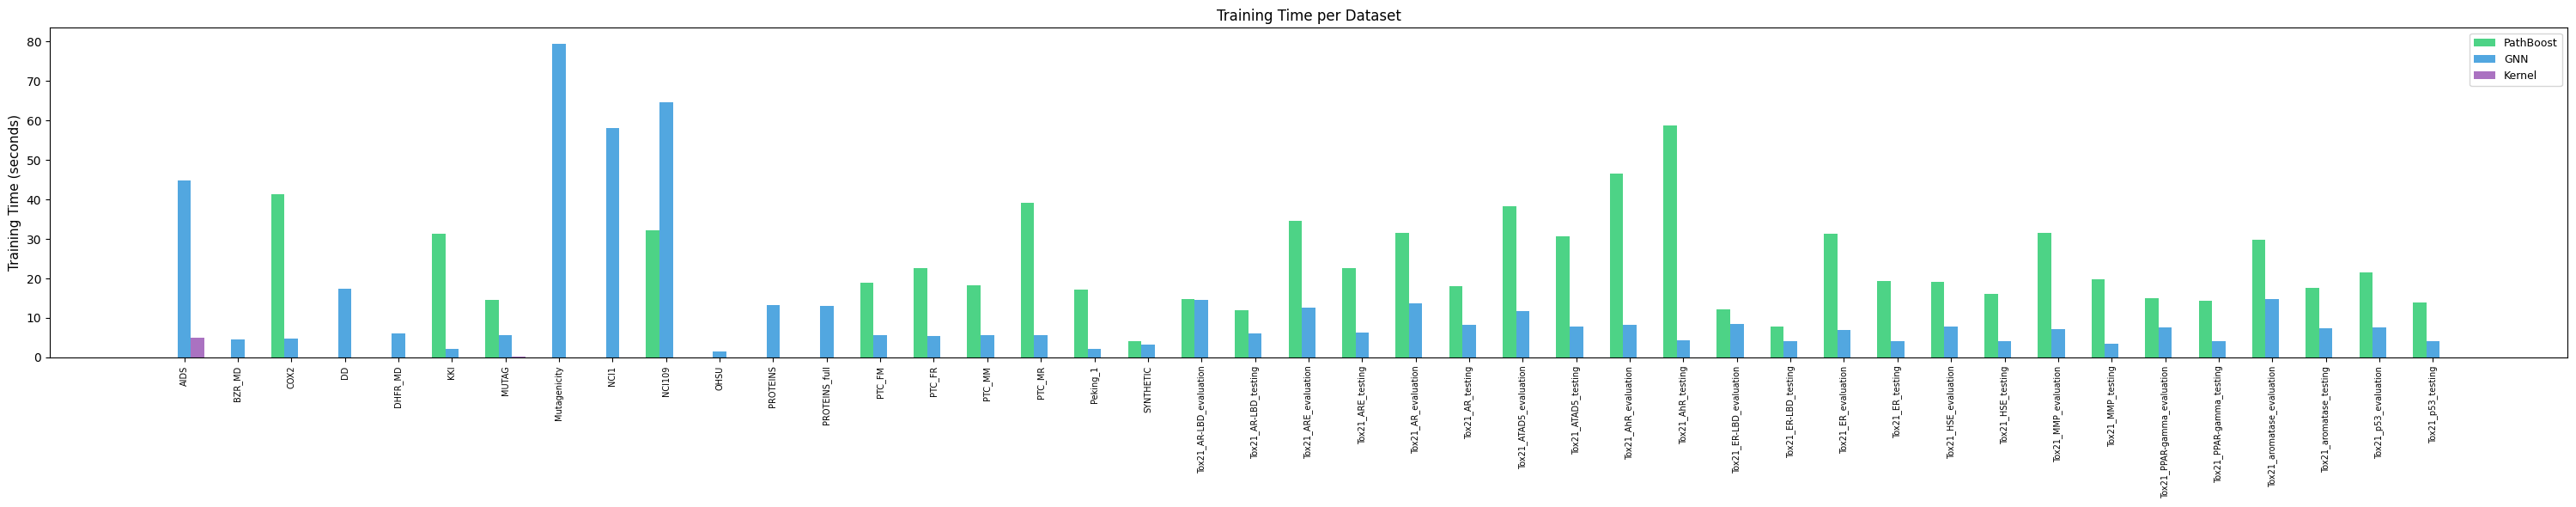


--- Training Time Summary (seconds) ---
  PathBoost: mean=24.0s, median=19.5s, max=58.8s (34 datasets)
  GNN: mean=12.3s, median=7.0s, max=79.5s (43 datasets)
  Kernel: mean=2.6s, median=2.6s, max=4.9s (2 datasets)


In [6]:
# Extract training time from accuracy rows (same per dataset regardless of metric)
def get_training_times(df, prefix):
    t = df[df['Metric'] == 'accuracy'][['Dataset', 'Training_Time_Mean', 'Training_Time_Std']].copy()
    t = t.rename(columns={
        'Training_Time_Mean': f'{prefix}_Time_Mean',
        'Training_Time_Std': f'{prefix}_Time_Std',
    })
    return t


time_pb = get_training_times(df_pb, 'PB')
time_gnn = get_training_times(df_gnn, 'GNN')

# Kernel: use first accuracy metric available
if len(df_kernel) > 0 and len(kernel_acc_metrics) > 0:
    k_time = df_kernel[df_kernel['Metric'].isin(kernel_acc_metrics)].copy()
    k_time = k_time.sort_values('Mean', ascending=False).drop_duplicates(subset=['Dataset'], keep='first')
    k_time = k_time[['Dataset', 'Training_Time_Mean', 'Training_Time_Std']].rename(columns={
        'Training_Time_Mean': 'Kernel_Time_Mean',
        'Training_Time_Std': 'Kernel_Time_Std',
    })
else:
    k_time = pd.DataFrame(columns=['Dataset', 'Kernel_Time_Mean', 'Kernel_Time_Std'])

time_df = time_pb.merge(time_gnn, on='Dataset', how='outer')
time_df = time_df.merge(k_time, on='Dataset', how='outer')
time_df = time_df.sort_values('Dataset').reset_index(drop=True)

# Round for display
for col in time_df.columns:
    if col != 'Dataset':
        time_df[col] = time_df[col].round(2)

print(f"Training times: {len(time_df)} datasets")
show(time_df, scrollY='400px', scrollCollapse=True, paging=False)

# Bar chart
n_datasets = len(time_df)
fig, ax = plt.subplots(figsize=(max(12, n_datasets * 0.7), 6))
x = np.arange(n_datasets)
width = 0.25

ax.bar(x - width, time_df['PB_Time_Mean'].fillna(0), width, label='PathBoost', color=COLOR_PB, alpha=0.85)
ax.bar(x, time_df['GNN_Time_Mean'].fillna(0), width, label='GNN', color=COLOR_GNN, alpha=0.85)
ax.bar(x + width, time_df['Kernel_Time_Mean'].fillna(0), width, label='Kernel', color=COLOR_KERNEL, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(time_df['Dataset'], rotation=90, fontsize=7)
ax.set_ylabel('Training Time (seconds)', fontsize=11)
ax.set_title('Training Time per Dataset', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n--- Training Time Summary (seconds) ---")
for name, col in [('PathBoost', 'PB_Time_Mean'), ('GNN', 'GNN_Time_Mean'), ('Kernel', 'Kernel_Time_Mean')]:
    vals = time_df[col].dropna()
    if len(vals) > 0:
        print(f"  {name}: mean={vals.mean():.1f}s, median={vals.median():.1f}s, max={vals.max():.1f}s ({len(vals)} datasets)")
    else:
        print(f"  {name}: no data")

## Summary

In [7]:
print("=" * 60)
print("OVERALL SUMMARY")
print("=" * 60)

for name, df, color in [('PathBoost', df_pb, COLOR_PB), ('GNN', df_gnn, COLOR_GNN)]:
    acc = df[df['Metric'] == 'accuracy']
    n = len(acc)
    if n > 0:
        mean_acc = acc['Mean'].mean() * 100
        best_row = acc.loc[acc['Mean'].idxmax()]
        worst_row = acc.loc[acc['Mean'].idxmin()]
        print(f"\n{name}:")
        print(f"  Datasets evaluated: {n}")
        print(f"  Mean accuracy: {mean_acc:.2f}%")
        print(f"  Best:  {best_row['Dataset']} ({best_row['Mean']*100:.2f}%)")
        print(f"  Worst: {worst_row['Dataset']} ({worst_row['Mean']*100:.2f}%)")
    else:
        print(f"\n{name}: no data")

# Kernel summary
if len(k_best) > 0:
    # k_best already has Kernel_Accuracy * 100 from cell 3
    n_k = len(k_best)
    mean_k = k_best['Kernel_Accuracy'].mean()
    best_k = k_best.loc[k_best['Kernel_Accuracy'].idxmax()]
    worst_k = k_best.loc[k_best['Kernel_Accuracy'].idxmin()]
    print(f"\nKernel (best of 7 variants):")
    print(f"  Datasets evaluated: {n_k}")
    print(f"  Mean accuracy: {mean_k:.2f}%")
    print(f"  Best:  {best_k['Dataset']} ({best_k['Kernel_Accuracy']:.2f}%)")
    print(f"  Worst: {worst_k['Dataset']} ({worst_k['Kernel_Accuracy']:.2f}%)")
else:
    print("\nKernel: no data (all FAILED/TIMEOUT)")

# Head-to-head on shared datasets
pb_acc_ds = set(df_pb[df_pb['Metric'] == 'accuracy']['Dataset'])
gnn_acc_ds = set(df_gnn[df_gnn['Metric'] == 'accuracy']['Dataset'])
shared = pb_acc_ds & gnn_acc_ds
print(f"\nHead-to-head (shared datasets): {len(shared)}")
if shared:
    pb_shared = df_pb[(df_pb['Metric'] == 'accuracy') & (df_pb['Dataset'].isin(shared))]['Mean'].mean() * 100
    gnn_shared = df_gnn[(df_gnn['Metric'] == 'accuracy') & (df_gnn['Dataset'].isin(shared))]['Mean'].mean() * 100
    print(f"  PB mean accuracy:  {pb_shared:.2f}%")
    print(f"  GNN mean accuracy: {gnn_shared:.2f}%")
    print(f"  Difference: {pb_shared - gnn_shared:+.2f}%")

OVERALL SUMMARY

PathBoost:
  Datasets evaluated: 34
  Mean accuracy: 83.61%
  Best:  Tox21_AR_testing (98.97%)
  Worst: KKI (53.00%)

GNN:
  Datasets evaluated: 43
  Mean accuracy: 81.45%
  Best:  Tox21_AR_testing (98.97%)
  Worst: SYNTHETIC (48.53%)

Kernel (best of 7 variants):
  Datasets evaluated: 2
  Mean accuracy: 92.54%
  Best:  AIDS (99.29%)
  Worst: MUTAG (85.79%)

Head-to-head (shared datasets): 34
  PB mean accuracy:  83.61%
  GNN mean accuracy: 83.42%
  Difference: +0.19%
